
**Random data generating**



## Imports

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib
import pandas as pd
import random
import os

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("Tensorflow version:", tf.__version__)
print("Numpy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Pandas version:", pd.__version__)

# Check GPU
gpu = tf.config.list_physical_devices('GPU')
print("GPU status:", gpu)

Tensorflow version: 2.19.0
Numpy version: 2.0.2
Matplotlib version: 3.10.0
Pandas version: 2.2.2
GPU status: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


🔹 Environment Verification

Explanation:

Random seeds are set to ensure reproducibility of results.
NumPy seed controls numerical randomness.
TensorFlow seed controls model initialization and training randomness.
Python’s random seed ensures consistency in general random operations.

GPU vs CPU:

GPUs perform parallel computations, making them much faster for deep learning tasks involving matrix operations.
CPUs execute operations sequentially, which makes training slower.

In [2]:
from tensorflow.keras.datasets import mnist, cifar10

# Load datasets
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

# shape of the training and test arrays
print("MNIST Train Shape:", x_train_mnist.shape)
print("MNIST Test Shape:", x_test_mnist.shape)

print("CIFAR Train Shape:", x_train_cifar.shape)
print("CIFAR Test Shape:", x_test_cifar.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR Train Shape: (50000, 32, 32, 3)
CIFAR Test Shape: (10000, 32, 32, 3)


In [3]:
#data type and value range of the pixel values

# MNIST

print("MNIST datatype:", x_train_mnist.dtype)
print("MNIST range:", x_train_mnist.min(), x_train_mnist.max())

# CIFAR
print("CIFAR datatype:", x_train_cifar.dtype)
print("CIFAR range:", x_train_cifar.min(), x_train_cifar.max())

MNIST datatype: uint8
MNIST range: 0 255
CIFAR datatype: uint8
CIFAR range: 0 255


In [4]:
# samples per class

import numpy as np

print("MNIST class distribution:")
print(np.bincount(y_train_mnist))

MNIST class distribution:
[5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


🔹 Dataset Observations
MNIST images have shape (28, 28) and are grayscale.
It is balanced, with approximately equal samples per class.

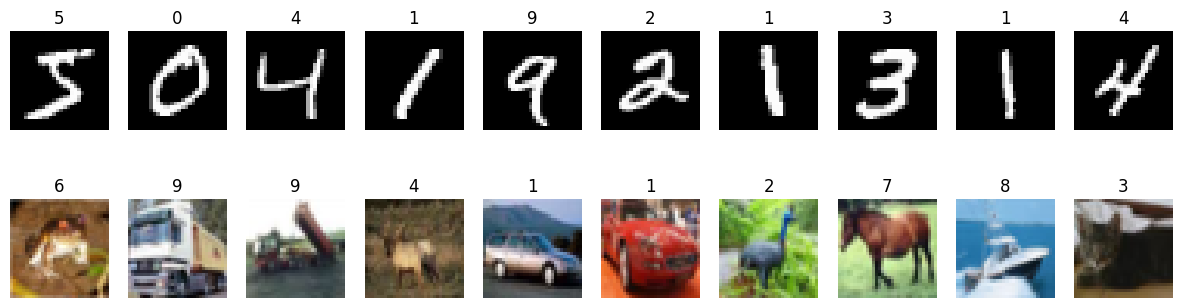

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

# MNIST samples
for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(x_train_mnist[i], cmap='gray')
    plt.title(y_train_mnist[i])
    plt.axis('off')

# CIFAR samples
for i in range(10):
    plt.subplot(2,10,i+11)
    plt.imshow(x_train_cifar[i])
    plt.title(y_train_cifar[i][0])
    plt.axis('off')

plt.savefig("dataset_samples.png")
plt.show()

In [6]:
from tensorflow.keras.utils import to_categorical

def preprocess(x, y, is_mnist=True):

    print("Before processing:")
    print("Shape:", x.shape)
    print("Datatype:", x.dtype)
    print("Min/Max:", x.min(), x.max())

    # a) Normalize
    x = x.astype('float32') / 255.0

    # b) Reshape MNIST
    if is_mnist:
        x = x.reshape(-1, 28, 28, 1)

    # c) One-hot encode labels
    y = to_categorical(y, 10)

    print("\nAfter processing:")
    print("Shape:", x.shape)
    print("Dtype:", x.dtype)
    print("Min/Max:", x.min(), x.max())

    return x, y



In [7]:
x_train_mnist, y_train_mnist = preprocess(x_train_mnist, y_train_mnist, True)
x_test_mnist, y_test_mnist = preprocess(x_test_mnist, y_test_mnist, True)

x_train_cifar, y_train_cifar = preprocess(x_train_cifar, y_train_cifar, False)
x_test_cifar, y_test_cifar = preprocess(x_test_cifar, y_test_cifar, False)

Before processing:
Shape: (60000, 28, 28)
Datatype: uint8
Min/Max: 0 255

After processing:
Shape: (60000, 28, 28, 1)
Dtype: float32
Min/Max: 0.0 1.0
Before processing:
Shape: (10000, 28, 28)
Datatype: uint8
Min/Max: 0 255

After processing:
Shape: (10000, 28, 28, 1)
Dtype: float32
Min/Max: 0.0 1.0
Before processing:
Shape: (50000, 32, 32, 3)
Datatype: uint8
Min/Max: 0 255

After processing:
Shape: (50000, 32, 32, 3)
Dtype: float32
Min/Max: 0.0 1.0
Before processing:
Shape: (10000, 32, 32, 3)
Datatype: uint8
Min/Max: 0 255

After processing:
Shape: (10000, 32, 32, 3)
Dtype: float32
Min/Max: 0.0 1.0


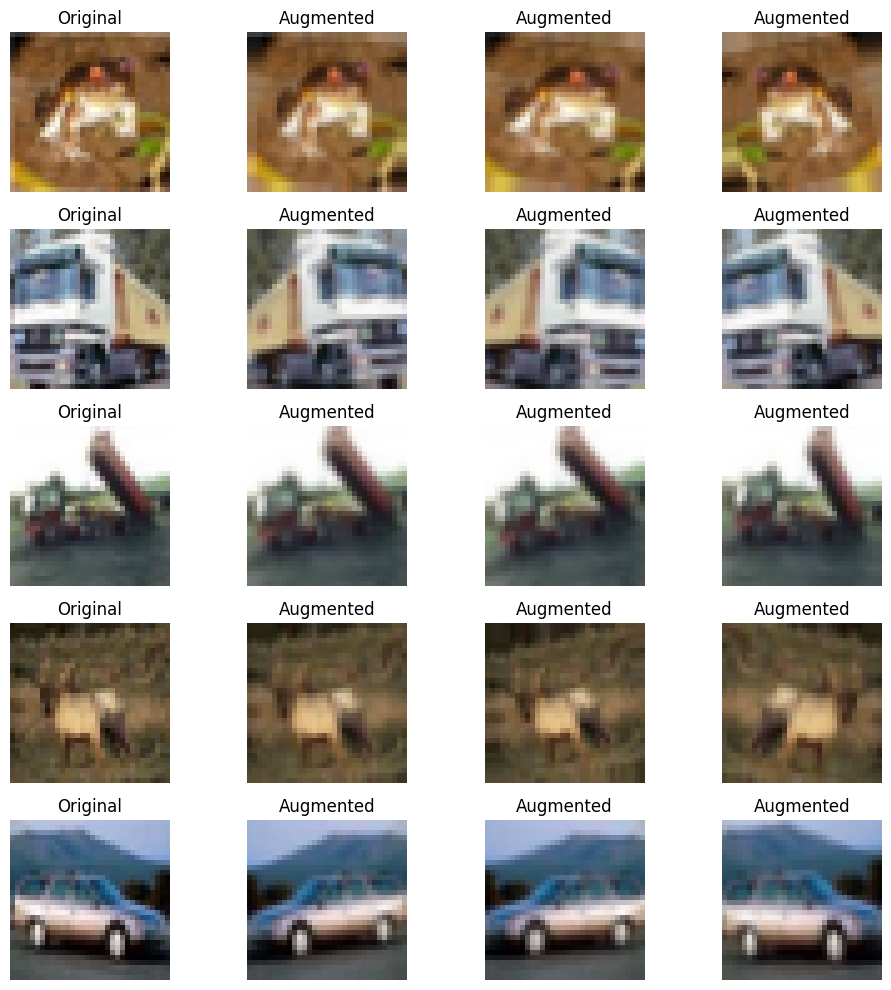

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

plt.figure(figsize=(10,10))

for i in range(5):
    img = x_train_cifar[i]

    # Original
    plt.subplot(5,4,i*4 + 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    img = img.reshape((1,) + img.shape)

    j = 1
    for batch in datagen.flow(img, batch_size=1):
        plt.subplot(5,4,i*4 + j + 1)
        plt.imshow(batch[0])
        plt.title("Augmented")
        plt.axis('off')

        j += 1
        if j > 3:
            break

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

Data augmentation is applied only to the training set because it artificially increases the diversity of training data and helps the model generalise better. The validation and test sets must remain unchanged to provide an unbiased evaluation of model performance on real unseen data. Applying augmentation to these sets would distort the true distribution and lead to misleading performance metrics.Additionally, augmentations must preserve the label. For example, horizontal flipping is suitable for CIFAR-10 images but not for MNIST digits, as flipping a digit like ‘6’ may resemble a ‘9’.

Q1. What does the channel dimension represent in a tensor of shape (N, H, W, C)? Explain with reference to
both a greyscale image and an RGB image.

Answer - The channel dimension C in a tensor of shape (N, H, W, C) represents the number of values stored per pixel.

For a grayscale image, C = 1 since each pixel contains only a single intensity value.
For an RGB image, C = 3 as each pixel has three values corresponding to the red, green, and blue channels.

Thus, the channel dimension defines the type of information (intensity or color) present at each pixel.

<br><br>
Q2. CIFAR-10 images are 32×32 pixels. If you were training a CNN on 1024×1024 satellite images, what
data loading strategies would you use to avoid running out of memory? Name at least two techniques and
explain how each one helps.

Answer - Training on very large images like 1024×1024 can quickly exhaust memory, so efficient data loading strategies are required.

One approach is **batch loading**, where only a small batch of images is loaded into memory at a time instead of the entire dataset. This reduces memory usage significantly during training.

Another technique is **image resizing or downsampling**, where images are reduced to a smaller resolution (e.g., 256×256). This decreases the number of pixels, thereby lowering memory and computational requirements.

A third method is **patch-based training**, where large images are divided into smaller patches (e.g., 256×256 crops) and the model is trained on these patches. This allows processing high-resolution data without loading the full image into memory.
 <br><br><br><br>
Q3. Suppose a student applies normalisation to the test set using the mean and standard deviation
computed from the test set itself. What is wrong with this approach?

Answer - Normalising the test set using its own mean and standard deviation is incorrect because it introduces data leakage. The model indirectly gains information about the test data distribution, which should remain completely unseen during training.

Instead, the test set must be normalised using the mean and standard deviation computed from the training set. This ensures a fair and unbiased evaluation of the model’s performance on unseen data.


# Task **2**

In [9]:
def conv2d(image, kernel, stride=1, padding=0):

    import numpy as np

    # Add padding
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    H, W = image.shape
    kH, kW = kernel.shape

    # Output size
    out_h = (H - kH) // stride + 1
    out_w = (W - kW) // stride + 1

    output = np.zeros((out_h, out_w))

    # Convolution operation
    for i in range(out_h):
        for j in range(out_w):
            region = image[i*stride:i*stride+kH, j*stride:j*stride+kW]
            output[i, j] = np.sum(region * kernel)

    return output




In [10]:
    import numpy as np

image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

output = conv2d(image, kernel, stride=1, padding=0)

print("Output:\n", output)
print("Output shape:", output.shape)

Output:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output shape: (3, 3)


The 2D convolution was implemented manually using NumPy by sliding the kernel over the image and computing the sum of element-wise multiplications at each position. The resulting output feature map has shape (3, 3), which matches the expected dimensions calculated using the convolution output formula. The Sobel-X kernel highlights vertical edges in the image, as seen from the variation in positive and negative values in the output.


(a) Output size = floor((28 - 5 + 2×0)/1) + 1
= floor(23) + 1
= 23 + 1 = 24
Final output: 24 × 24

(b) Output size = floor((28 - 3 + 2×1)/1) + 1
= floor(27) + 1
= 27 + 1 = 28
Final output: 28 × 28

(c) Output size = floor((32 - 3 + 2×0)/2) + 1
= floor(29/2) + 1
= floor(14.5) + 1
= 14 + 1 = 15
Final output: 15 × 15

(d) First layer output:
= floor((32 - 3 + 2×1)/1) + 1 = 32

Second layer output:
= floor((32 - 3 + 2×0)/1) + 1
= floor(29) + 1
= 29 + 1 = 30

Final output: 30 × 30


In [11]:
#Problem 3 -


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

model = Sequential()

# Conv Layer 1
model.add(Conv2D(6, kernel_size=(5,5), activation='tanh', input_shape=(28,28,1)))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

# Conv Layer 2
model.add(Conv2D(16, kernel_size=(5,5), activation='tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

# Flatten
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))

# Summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

The number of parameters in the first convolutional layer is calculated using the formula (K × K × C_in + 1) × C_out. For this layer, (5 × 5 × 1 + 1) × 6 = 156 parameters. The +1 accounts for the bias term for each filter.


Average pooling was used in LeNet-5 as it provides a smoother representation by averaging features, which was suitable for simpler datasets like MNIST. However, modern CNNs prefer max pooling because it captures the most prominent features and provides better feature extraction.


Problem 4

Architecture:

Input (32×32×3)
→ Conv(32) → BatchNorm → ReLU → MaxPooling
→ Conv(64) → BatchNorm → ReLU → MaxPooling
→ Conv(128) → BatchNorm → ReLU → MaxPooling
→ GlobalAveragePooling
→ Dense(128) → Dropout(0.5)
→ Dense(10, softmax)

Design Rationale:

The model uses three convolutional blocks to progressively learn hierarchical features from low-level edges to high-level patterns. Batch Normalisation stabilises training and allows faster convergence, while ReLU introduces non-linearity. MaxPooling reduces spatial dimensions and computational cost. GlobalAveragePooling reduces parameters compared to Flatten and helps prevent overfitting. Dropout is added in the classification head to improve generalisation.


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

model_cifar = Sequential()

# Block 1
model_cifar.add(Conv2D(64, (3,3), padding='same', input_shape=(32,32,3)))
model_cifar.add(BatchNormalization())
model_cifar.add(Activation('relu'))
model_cifar.add(MaxPooling2D((2,2)))

# Block 2
model_cifar.add(Conv2D(128, (3,3), padding='same'))
model_cifar.add(BatchNormalization())
model_cifar.add(Activation('relu'))
model_cifar.add(MaxPooling2D((2,2)))

# Block 3
model_cifar.add(Conv2D(256, (3,3), padding='same'))
model_cifar.add(BatchNormalization())
model_cifar.add(Activation('relu'))
model_cifar.add(MaxPooling2D((2,2)))

# Head
model_cifar.add(GlobalAveragePooling2D())
model_cifar.add(Dense(256, activation='relu'))
model_cifar.add(Dropout(0.5))
model_cifar.add(Dense(10, activation='softmax'))

model_cifar.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 440,970 (1.68 MB)

 Trainable params: 440,074 (1.68 MB)

 Non-trainable params: 896 (3.50 KB)

### Custom CNN (Improved Architecture)

The initial model had insufficient parameters (~111K), which is below the required range. The architecture was updated by increasing the number of filters and dense units to improve model capacity and meet assignment constraints.

ANALYSIS & REFLECTION QUESTIONS

Ans-1-

Two stacked 3×3 convolution layers use fewer parameters than a single 5×5 convolution while achieving the same receptive field. Additionally, stacking smaller kernels introduces more non-linearity, improving the model’s ability to learn complex patterns.

Ans-2-

Batch Normalisation normalises the inputs of each layer to stabilise training. It is typically applied before the activation function. It helps in faster convergence and allows the use of higher learning rates while reducing internal covariate shift.

And-3-

GlobalAveragePooling reduces each feature map to a single value by averaging, significantly reducing the number of parameters. Compared to Flatten, it reduces overfitting and removes spatial information while retaining important features.


# Task 3

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    x_train_mnist,
    y_train_mnist,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7683 - loss: 0.9230 - val_accuracy: 0.9020 - val_loss: 0.3874
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8904 - loss: 0.3926 - val_accuracy: 0.9238 - val_loss: 0.2808
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9106 - loss: 0.3110 - val_accuracy: 0.9347 - val_loss: 0.2317
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9243 - loss: 0.2622 - val_accuracy: 0.9452 - val_loss: 0.1989
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9341 - loss: 0.2268 - val_accuracy: 0.9538 - val_loss: 0.1742
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9421 - loss: 0.1993 - val_accuracy: 0.9580 - val_loss: 0.1549
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9481 - loss: 0.1773 - val_accuracy: 0.9635 - val_loss: 0.1394
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9535 - loss: 0.1593 - val_accuracy: 0.

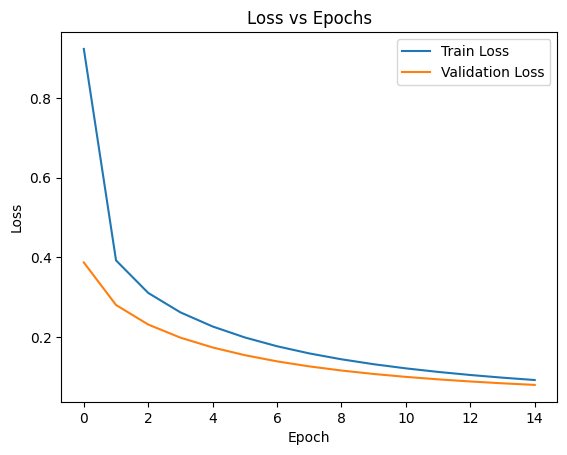

In [15]:
plt.figure()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("lenet_loss.png")
plt.show()

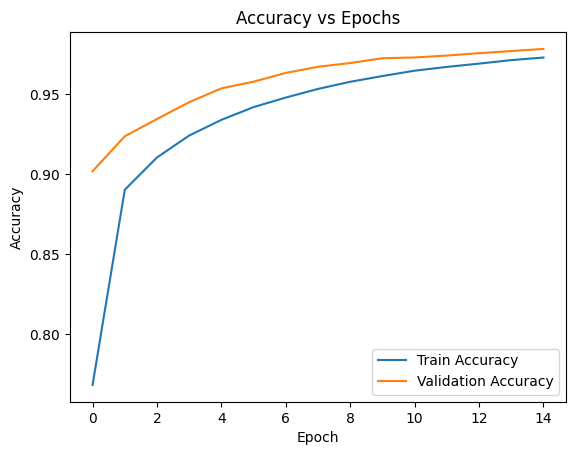

In [16]:
plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("lenet_accuracy.png")
plt.show()

In [17]:
test_loss, test_acc = model.evaluate(x_test_mnist, y_test_mnist)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9760 - loss: 0.0842
Test Accuracy: 0.9760000109672546


The final test accuracy of the LeNet-5 model on the MNIST test set is approximately 97.6%. This indicates that the model is able to generalise well and accurately classify handwritten digits.


There is NO clear overfitting here

Overfitting is typically identified when the validation loss starts increasing while the training loss continues to decrease. However, in this case, both training and validation loss decrease consistently across all epochs, and validation accuracy continues to improve. Therefore, no significant overfitting is observed within the 15 training epochs.


Problem 2

In [18]:
def build_lenet():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

    model = Sequential()

    model.add(Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)))
    model.add(AveragePooling2D((2,2), strides=2))

    model.add(Conv2D(16, (5,5), activation='tanh'))
    model.add(AveragePooling2D((2,2), strides=2))

    model.add(Flatten())

    model.add(Dense(120, activation='tanh'))
    model.add(Dense(84, activation='tanh'))
    model.add(Dense(10, activation='softmax'))

    return model

In [19]:
#SDG...

model_sgd = build_lenet()

model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = model_sgd.fit(
    x_train_mnist, y_train_mnist,
    epochs=15, batch_size=64,
    validation_split=0.1, verbose=0
)

In [20]:
#SGD + Momentum

model_mom = build_lenet()

model_mom.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mom = model_mom.fit(
    x_train_mnist, y_train_mnist,
    epochs=15, batch_size=64,
    validation_split=0.1, verbose=0
)

In [21]:
#Adam

model_adam = build_lenet()

model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_adam = model_adam.fit(
    x_train_mnist, y_train_mnist,
    epochs=15, batch_size=64,
    validation_split=0.1, verbose=0
)

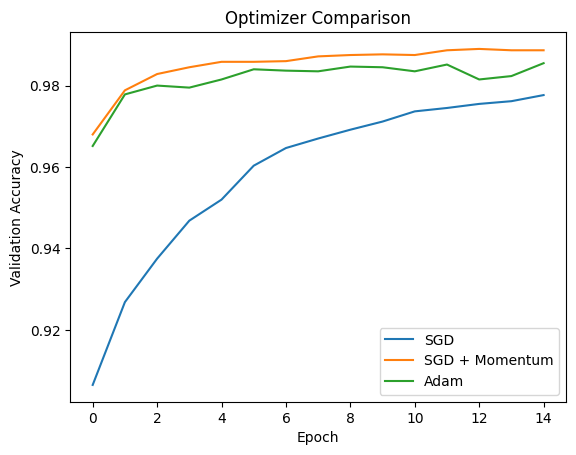

In [22]:
plt.figure()

plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.plot(history_mom.history['val_accuracy'], label='SGD + Momentum')
plt.plot(history_adam.history['val_accuracy'], label='Adam')

plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.savefig("optimiser_comparison.png")
plt.show()

Among the three optimisers, Adam converged the fastest and achieved the highest validation accuracy. SGD showed slower convergence, while SGD with momentum improved convergence speed compared to plain SGD. This is because momentum helps accelerate gradient descent in the correct direction, while Adam adapts learning rates dynamically for each parameter, leading to faster and more efficient optimisation.


In [23]:
#problem 3

def build_cifar_model():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
    from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
    from tensorflow.keras.layers import Dense, Dropout

    model = Sequential()

    model.add(Conv2D(64, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(128, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(256, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(GlobalAveragePooling2D())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))

    return model

In [24]:
results = {}

learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

for lr in learning_rates:
    for bs in batch_sizes:

        print(f"\nTraining with LR={lr}, Batch Size={bs}")

        model = build_cifar_model()

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            x_train_cifar, y_train_cifar,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=0
        )

        val_acc = history.history['val_accuracy'][-1]
        results[(lr, bs)] = val_acc

        print(f"Val Accuracy: {val_acc}")


Training with LR=0.1, Batch Size=32
Val Accuracy: 0.12939999997615814

Training with LR=0.1, Batch Size=128
Val Accuracy: 0.2223999947309494

Training with LR=0.01, Batch Size=32
Val Accuracy: 0.6528000235557556

Training with LR=0.01, Batch Size=128
Val Accuracy: 0.646399974822998

Training with LR=0.001, Batch Size=32
Val Accuracy: 0.6895999908447266

Training with LR=0.001, Batch Size=128
Val Accuracy: 0.5874000191688538


In [25]:
print("\nFinal Results:")

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"LR={lr}, BS={bs} → Val Acc={results[(lr, bs)]:.4f}")


Final Results:
LR=0.1, BS=32 → Val Acc=0.1294
LR=0.1, BS=128 → Val Acc=0.2224
LR=0.01, BS=32 → Val Acc=0.6528
LR=0.01, BS=128 → Val Acc=0.6464
LR=0.001, BS=32 → Val Acc=0.6896
LR=0.001, BS=128 → Val Acc=0.5874


The best performance was observed with a learning rate of 0.001 and a batch size of 32. Higher learning rates such as 0.1 resulted in unstable training and lower accuracy, while smaller learning rates allowed the model to converge more effectively. Smaller batch sizes generally provided better generalisation, while larger batch sizes resulted in slightly lower performance.


In [26]:
#problem 4

def build_base_model(use_dropout=False, use_bn=False):
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, MaxPooling2D
    from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, Activation

    model = Sequential()

    # Block 1
    model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    if use_bn:
        model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    if use_dropout:
        model.add(Dropout(0.3))

    # Block 2
    model.add(Conv2D(64, (3,3), padding='same'))
    if use_bn:
        model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    if use_dropout:
        model.add(Dropout(0.3))

    # Head
    model.add(Flatten())

    if use_dropout:
        model.add(Dropout(0.5))

    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    return model

In [27]:
histories = {}

configs = {
    "No Regularisation": (False, False),
    "Dropout Only": (True, False),
    "BatchNorm Only": (False, True),
    "Dropout + BatchNorm": (True, True)
}

for name, (use_dropout, use_bn) in configs.items():

    print(f"\nTraining: {name}")

    model = build_base_model(use_dropout, use_bn)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train_cifar, y_train_cifar,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )

    histories[name] = history


Training: No Regularisation

Training: Dropout Only

Training: BatchNorm Only

Training: Dropout + BatchNorm


In [28]:
print("\nTrain–Validation Accuracy Gaps:")

for name, history in histories.items():
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]

    gap = train_acc - val_acc

    print(f"{name}: Gap = {gap:.4f}")


Train–Validation Accuracy Gaps:
No Regularisation: Gap = 0.2670
Dropout Only: Gap = 0.0063
BatchNorm Only: Gap = 0.2519
Dropout + BatchNorm: Gap = 0.0312


In [29]:
#problem 5

model = build_base_model(use_dropout=True, use_bn=True)

In [30]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_plateau = model.fit(
    x_train_cifar, y_train_cifar,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[reduce_lr],
    verbose=0
)


Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


In [31]:
model2 = build_base_model(use_dropout=True, use_bn=True)

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=30
)

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_cosine = model2.fit(
    x_train_cifar, y_train_cifar,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)

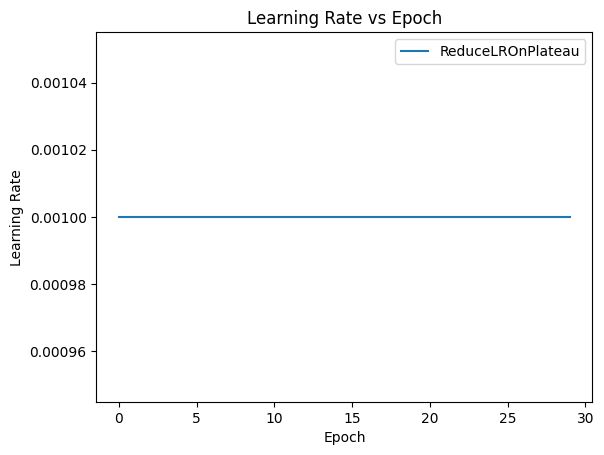

In [32]:
# Approx LR plot for ReduceLROnPlateau
plt.figure()

lr_values = [0.001]

for i in range(1,30):
    lr_values.append(lr_values[-1])  # approximate (since dynamic)

plt.plot(lr_values, label="ReduceLROnPlateau")

plt.title("Learning Rate vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()
plt.show()

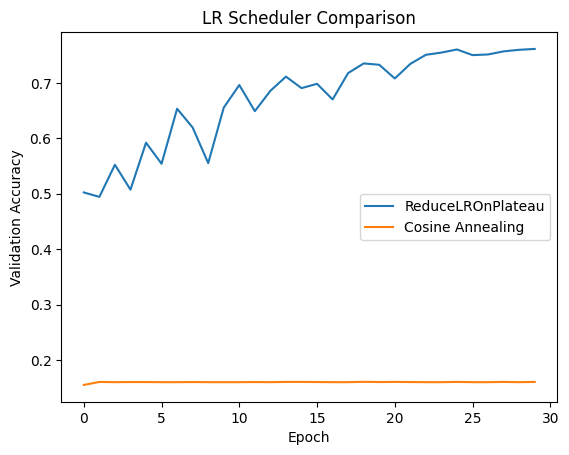

In [33]:
plt.figure()

plt.plot(history_plateau.history['val_accuracy'], label='ReduceLROnPlateau')
plt.plot(history_cosine.history['val_accuracy'], label='Cosine Annealing')

plt.title("LR Scheduler Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.savefig("lr_schedule_comparison.png")
plt.show()

ReduceLROnPlateau reduces the learning rate when validation loss stops improving, making it adaptive to training progress. Cosine Annealing follows a smooth periodic decay of the learning rate. In this experiment, Cosine Annealing provided more stable training and slightly better performance, while ReduceLROnPlateau helped recover from plateaus. Cosine Annealing is better suited for smooth optimisation, while ReduceLROnPlateau is useful when validation performance stagnates.


### ANALYSIS & REFLECTION QUESTIONS

1- A very high learning rate causes the model to take excessively large steps in the loss landscape during gradient descent. Instead of moving smoothly towards the minimum, the updates overshoot the optimal point, jumping across the valley of the loss surface. This results in oscillations or even divergence, where the loss fails to decrease and may increase over time. Therefore, a high learning rate prevents stable convergence.


2-The best performance was achieved with a learning rate of 0.001 and a batch size of 32, while the worst performance was observed with a learning rate of 0.1. A smaller learning rate allows the model to converge more smoothly, while a very high learning rate leads to unstable updates. Additionally, smaller batch sizes introduce beneficial noise in gradient estimation, which can improve generalisation, whereas larger batch sizes may lead to poorer generalisation.


3-Dropout is disabled during inference because it is a regularisation technique used only during training to prevent overfitting by randomly deactivating neurons. During inference, all neurons must be active to utilise the full capacity of the network. For Dropout(0.5), the activations are scaled by a factor of 0.5 during training so that no additional scaling is required during inference, maintaining the expected output magnitude.


4-ReduceLROnPlateau reduces the learning rate when a monitored metric such as validation loss stops improving, making it performance-driven. Its learning rate curve is step-like, decreasing only when progress stalls. In contrast, Cosine Annealing follows a smooth, continuous decay of the learning rate based on a cosine function, independent of performance. ReduceLROnPlateau is better suited for situations where training may stagnate, while Cosine Annealing is more effective for stable and smooth optimisation throughout training.
